# Lab 6: Harris Corner Detection, Shi-Tomasi Corner Detector, and Good Features to Track in OpenCV
This lab focuses on detecting corners in images using Harris Corner Detection and Shi-Tomasi Corner Detector (Good Features to Track) with OpenCV. The exercises cover corner detection, visualization, and comparison of results. Code is designed for a Jupyter Notebook, with images displayed inline using matplotlib.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Exercise 1: Harris Corner Detection
Task: Apply Harris Corner Detection to an image and visualize the detected corners.

(-0.5, 799.5, 449.5, -0.5)

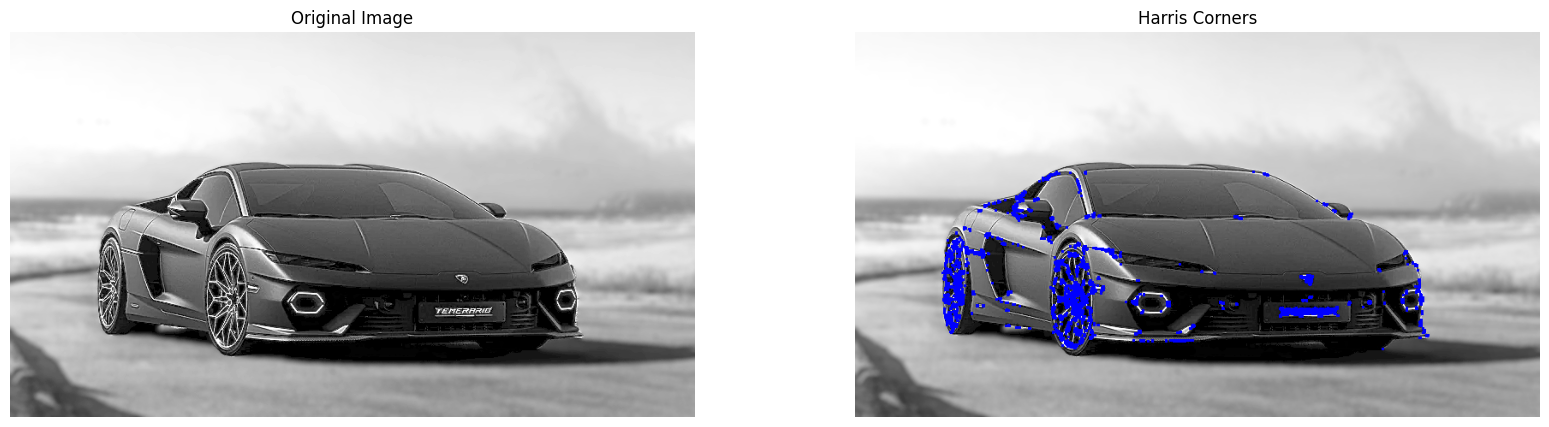

In [2]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Convert to float32 for Harris
img_float = np.float32(img)

# Apply Harris Corner Detection
dst = cv2.cornerHarris(img_float, blockSize=2, ksize=3, k=0.04)

# Dilate to mark corners
dst = cv2.dilate(dst, None)

# Threshold to highlight strong corners
img_corners = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
img_corners[dst > 0.01 * dst.max()] = [0, 0, 255]  # Mark corners in red

# Display images
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Harris Corners')
plt.imshow(img_corners)
plt.axis('off')


## Exercise 2: Shi-Tomasi Corner Detector (Good Features to Track)
Task: Use Shi-Tomasi Corner Detector to find strong corners and visualize them.

/tmp/ipykernel_13/196395782.py:15: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  corners = np.int0(corners)


(-0.5, 799.5, 449.5, -0.5)

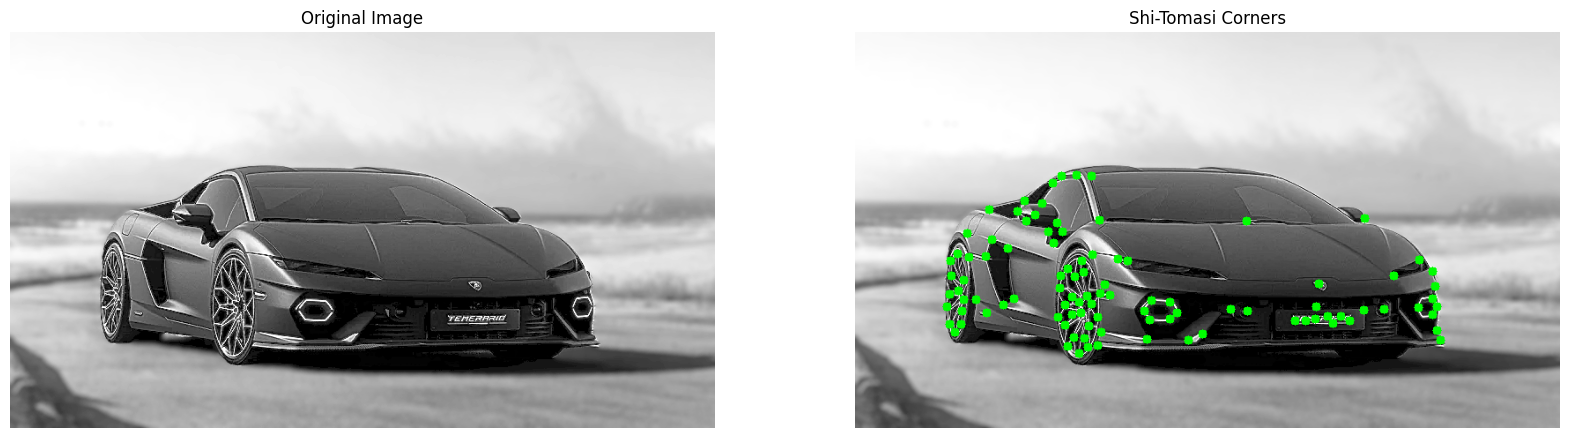

In [3]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Detect corners using Shi-Tomasi
corners = cv2.goodFeaturesToTrack(img, maxCorners=100, qualityLevel=0.01, minDistance=10)

# Convert to color for visualization
img_corners = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

# Draw circles at detected corners
if corners is not None:
    corners = np.int0(corners)
    for corner in corners:
        x, y = corner.ravel()
        cv2.circle(img_corners, (x, y), 5, (0, 255, 0), -1)

# Display images
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Shi-Tomasi Corners')
plt.imshow(img_corners)
plt.axis('off')


## Exercise 3: Comparing Harris and Shi-Tomasi
Task: Apply both detectors to the same image and compare the results.

/tmp/ipykernel_13/2640473076.py:18: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  corners = np.int0(corners)


(-0.5, 799.5, 449.5, -0.5)

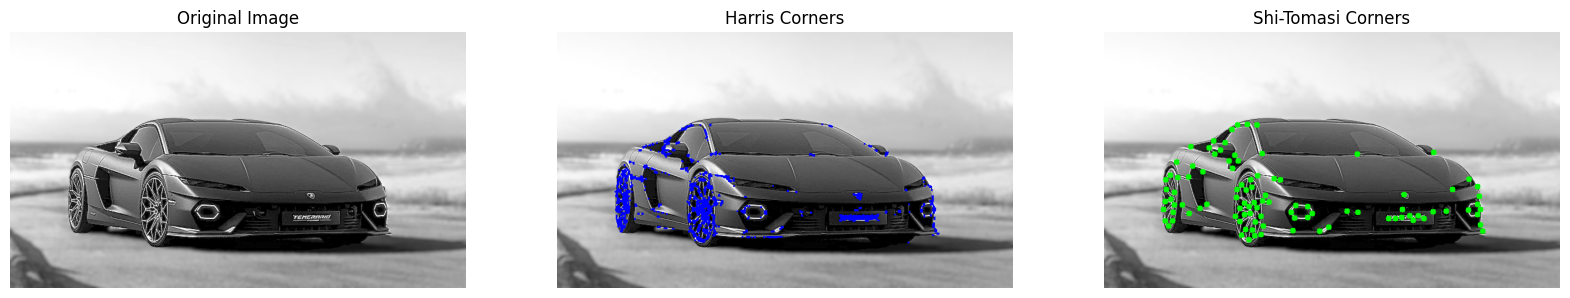

In [4]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Harris Corner Detection
img_float = np.float32(img)
dst = cv2.cornerHarris(img_float, blockSize=2, ksize=3, k=0.04)
dst = cv2.dilate(dst, None)
img_harris = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]

# Shi-Tomasi Corner Detection
corners = cv2.goodFeaturesToTrack(img, maxCorners=100, qualityLevel=0.01, minDistance=10)
img_shi = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
if corners is not None:
    corners = np.int0(corners)
    for corner in corners:
        x, y = corner.ravel()
        cv2.circle(img_shi, (x, y), 5, (0, 255, 0), -1)

# Display results
plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Harris Corners')
plt.imshow(img_harris)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Shi-Tomasi Corners')
plt.imshow(img_shi)
plt.axis('off')

# By **Saddam Umer**

BS AI, SMIU